final code for training capped at 300 dishes 

In [1]:
!pip install timm==0.9.8

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.2 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: timm
    Found existing installation: timm 1.0.25
    Uninstalling timm-1.0.25:
      Successfully uninstalled timm-1.0.25


In [2]:
pip install timm --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 34.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: timm
    Found existing installation: timm 0.9.8
    Uninstalling timm-0.9.8:
      Successfully uninstalled timm-0.9.8
Note: you may need to restart the kernel to use updated packages.


In [15]:
# ==================================================================================
# SEHATGURU FINAL 50-CLASS TRAINING PIPELINE — CAPPED TRAINING VERSION
# Stage 1: Food-101 pretraining
# Stage 2: SehatGuru 50-class fine-tuning with max 400 training images per class
#
# Important change:
# - Dataset is split first into train/val/test.
# - Only the TRAIN split is capped to max 400 images per class.
# - Validation and test remain unchanged.
#
# Dataset replacement update:
# - Removes: Charga, Palak Paneer, Sheer khurma
# - Adds Food-101: Donut, Dumpling, French Toast
# - Each added class capped at 300 images
#
# Saves:
# - Food-101 checkpoint
# - best capped SehatGuru model checkpoint
# - last capped SehatGuru checkpoint
# - classification report
# - confidence report
# - confusion matrix
# - hard examples CSV
# - confusion-pair CSV
# - split indices JSON
# - training history CSV
# - final downloadable ZIP
# ==================================================================================


# ==================================================================================
# 0. IMPORTS / INSTALLS
# ==================================================================================

import os
import json
import time
import copy
import random
import shutil
from pathlib import Path

try:
    import timm
except ImportError:
    os.system("pip install -q timm")
    import timm

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt


# ==================================================================================
# 1. CONFIG
# ==================================================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP_ENABLED = DEVICE == "cuda"

SEED = 42

# DINOv2 ViT-B/14 works best with sizes divisible by 14
IMG_SIZE = 252

# Keep 16 initially.
# Reduce to 12 or 8 only if Kaggle GPU runs out of memory.
BATCH_SIZE = 16

NUM_WORKERS = 2

EXPECTED_CLASSES = 50

# Only training data is capped
TRAIN_CAP_PER_CLASS = 300

# ==================================================================================
# FOOD-101 PRETRAINING
# ==================================================================================

USE_FOOD101_PRETRAINING = True
REUSE_FOOD101_CKPT_IF_EXISTS = True

# DINOv2 already has very strong pretrained representations,
# but keeping 3 epochs for fair comparison vs ConvNeXt pipeline.
FOOD101_EPOCHS = 3

FOOD101_ROOT = "/kaggle/working/torchvision_food101"

# ==================================================================================
# SEHATGURU FINE-TUNING
# ==================================================================================
# Total epochs = 3 + 8 + 18 = 29

PHASES = [
    {
        "name": "head_only",
        "epochs": 3,
        "mode": "head_only",
        "backbone_lr": 0.0,
        "head_lr": 3e-4,
    },
    {
        "name": "last_stage",
        "epochs": 8,
        "mode": "last_stage",
        "backbone_lr": 1e-5,
        "head_lr": 1e-4,
    },
    {
        "name": "full_finetune",
        "epochs": 18,
        "mode": "all",
        "backbone_lr": 5e-6,
        "head_lr": 5e-5,
    },
]

# ==================================================================================
# TRAINING OPTIONS
# ==================================================================================

USE_FOCAL_LOSS = True
USE_WEIGHTED_SAMPLER = False

# Mixup kept; CutMix removed
USE_MIXUP_CUTMIX = True

USE_EMA = True
USE_TRIVIAL_AUGMENT = True

# Slightly lower mixup for ViTs
MIXUP_ALPHA = 0.1

EMA_DECAY = 0.999

WEIGHT_DECAY = 1e-2
GRAD_CLIP = 1.0

# ==================================================================================
# DATASET
# ==================================================================================

DATASET_DIR = "/kaggle/input/datasets/ahtishamuwu/sehatguru-dishes-50/50_dishes_dataset"

# Remove problematic/confusing classes
REMOVE_MAIN_CLASSES = {
    "Charga",
    "Palak Paneer",
    "Sheer Khurma",
}

# ==================================================================================
# EXTRA FOOD-101 CLASSES
# ==================================================================================

EXTRA_FOOD101_CLASS_SPECS = [
    {
        "display_name": "Donut",
        "keywords": ["donuts", "donut", "doughnuts", "doughnut"],
    },
    {
        "display_name": "Dumpling",
        "keywords": ["dumplings", "dumpling"],
    },
    {
        "display_name": "French Toast",
        "keywords": ["french toast", "french_toast"],
    },
]

EXTRA_CLASS_MAX = 300

# ==================================================================================
# OUTPUT FILES
# ==================================================================================

# DINOv2-specific checkpoint names
FOOD101_CKPT = "/kaggle/working/stage1_food101_dinov2_vitb14.pth"

FINAL_CKPT = "/kaggle/working/SehatGuru_DINOv2_50_capped300_best_macroF1.pth"

LAST_CKPT = "/kaggle/working/SehatGuru_DINOv2_50_capped300_last.pth"

CONFUSION_PNG = "/kaggle/working/confusion_matrix_50_classes_capped300.png"

CONFIDENCE_CSV = "/kaggle/working/confidence_report_50_classes_capped300.csv"

REPORT_CSV = "/kaggle/working/classification_report_50_classes_capped300.csv"

HARD_EXAMPLES_CSV = "/kaggle/working/hard_examples_50_classes_capped300.csv"

CONFUSION_PAIRS_CSV = "/kaggle/working/top_confusion_pairs_50_classes_capped300.csv"

SPLIT_JSON = "/kaggle/working/sehatguru_50_split_indices_capped300.json"

TRAINING_HISTORY_CSV = "/kaggle/working/training_history_50_classes_capped300.csv"

OUTPUT_ZIP = "/kaggle/working/sehatguru_50_capped300_training_outputs.zip"


# ==================================================================================
# 2. AMP HELPERS
# ==================================================================================

try:
    from torch.amp import GradScaler, autocast

    def make_scaler():
        return GradScaler("cuda", enabled=AMP_ENABLED)

    def amp_context():
        return autocast("cuda", enabled=AMP_ENABLED)

except Exception:
    from torch.cuda.amp import GradScaler, autocast

    def make_scaler():
        return GradScaler(enabled=AMP_ENABLED)

    def amp_context():
        return autocast(enabled=AMP_ENABLED)


# ==================================================================================
# 3. REPRODUCIBILITY
# ==================================================================================

def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


seed_everything(SEED)

print("=" * 90)
print("SEHATGURU FINAL 50-CLASS TRAINING PIPELINE — CAPPED TRAINING VERSION")
print("=" * 90)
print("Device:", DEVICE)
print("AMP enabled:", AMP_ENABLED)
print("Food-101 pretraining:", USE_FOOD101_PRETRAINING)
print("Reuse Food-101 checkpoint if exists:", REUSE_FOOD101_CKPT_IF_EXISTS)
print("Food-101 root:", FOOD101_ROOT)
print("SehatGuru dataset:", DATASET_DIR)
print("Batch size:", BATCH_SIZE)
print("Training cap per class:", TRAIN_CAP_PER_CLASS)
print("Remove main classes:", REMOVE_MAIN_CLASSES)
print("Add Food-101 classes:", [x["display_name"] for x in EXTRA_FOOD101_CLASS_SPECS])


# ==================================================================================
# 4. TRANSFORMS
# ==================================================================================

def build_train_transform():
    aug_list = [
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.45, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(12),
    ]

    if USE_TRIVIAL_AUGMENT:
        try:
            aug_list.append(transforms.TrivialAugmentWide())
            print("\nUsing TrivialAugmentWide.")
        except AttributeError:
            print("\nTrivialAugmentWide not available. Skipping it.")

    aug_list.extend([
        transforms.ColorJitter(
            brightness=0.20,
            contrast=0.20,
            saturation=0.20,
            hue=0.01,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225],
        ),
    ])

    return transforms.Compose(aug_list)


train_transform = build_train_transform()

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225],
    ),
])


# ==================================================================================
# 5. SAFE IMAGEFOLDER + SUBSET WRAPPER
# ==================================================================================

class SafeImageFolder(datasets.ImageFolder):
    def __init__(self, *args, max_retries=10, **kwargs):
        super().__init__(*args, **kwargs)
        self.max_retries = max_retries
        self.bad_images_seen = 0

    def __getitem__(self, index):
        for offset in range(self.max_retries):
            safe_index = (index + offset) % len(self.samples)
            path, target = self.samples[safe_index]

            try:
                sample = self.loader(path)

                if self.transform is not None:
                    sample = self.transform(sample)

                if self.target_transform is not None:
                    target = self.target_transform(target)

                return sample, target

            except Exception as e:
                self.bad_images_seen += 1

                if self.bad_images_seen <= 20:
                    print(f"Skipping unreadable image: {path} | {type(e).__name__}")

                continue

        raise RuntimeError(f"Could not load a valid image near index {index}")


class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, label = self.base_dataset[real_idx]

        if self.transform:
            image = self.transform(image)

        return image, label

    def __len__(self):
        return len(self.indices)


# ==================================================================================
# 6. DATASET HELPERS
# ==================================================================================

def get_targets_from_dataset(dataset):
    if hasattr(dataset, "targets"):
        return list(dataset.targets)

    targets = []
    for i in range(len(dataset)):
        _, label = dataset[i]
        targets.append(label)

    return targets


def stratified_split_indices(labels, train_ratio=0.80, val_ratio=0.10, test_ratio=0.10, seed=42):
    labels = np.array(labels)
    all_indices = np.arange(len(labels))

    ratio_sum = train_ratio + val_ratio + test_ratio

    if abs(ratio_sum - 1.0) > 1e-6:
        raise ValueError("train_ratio + val_ratio + test_ratio must equal 1.0")

    counts = np.bincount(labels)

    if counts.min() < 3:
        print("\nWarning: Some classes have fewer than 3 samples. Falling back to random split.")

        rng = np.random.default_rng(seed)
        rng.shuffle(all_indices)

        train_end = int(train_ratio * len(all_indices))
        val_end = train_end + int(val_ratio * len(all_indices))

        return (
            all_indices[:train_end].tolist(),
            all_indices[train_end:val_end].tolist(),
            all_indices[val_end:].tolist(),
        )

    if test_ratio == 0:
        train_idx, val_idx = train_test_split(
            all_indices,
            test_size=val_ratio,
            random_state=seed,
            stratify=labels,
        )

        return train_idx.tolist(), val_idx.tolist(), []

    train_idx, temp_idx = train_test_split(
        all_indices,
        test_size=(1 - train_ratio),
        random_state=seed,
        stratify=labels,
    )

    temp_labels = labels[temp_idx]
    val_fraction_of_temp = val_ratio / (val_ratio + test_ratio)

    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=(1 - val_fraction_of_temp),
        random_state=seed,
        stratify=temp_labels,
    )

    return train_idx.tolist(), val_idx.tolist(), test_idx.tolist()


def cap_train_indices_per_class(train_indices, labels, max_per_class=400, seed=42):
    """
    Caps only the training set.
    Validation and test are left untouched.
    """

    rng = np.random.default_rng(seed)
    labels = np.array(labels)

    class_to_indices = {}

    for idx in train_indices:
        label = int(labels[idx])
        class_to_indices.setdefault(label, []).append(idx)

    capped_indices = []
    cap_report = []

    for label in sorted(class_to_indices.keys()):
        indices = class_to_indices[label]
        before_count = len(indices)

        if before_count > max_per_class:
            selected = rng.choice(indices, size=max_per_class, replace=False).tolist()
        else:
            selected = indices

        after_count = len(selected)
        capped_indices.extend(selected)

        cap_report.append({
            "class_id": label,
            "before_cap": before_count,
            "after_cap": after_count,
            "removed": before_count - after_count,
        })

    rng.shuffle(capped_indices)

    return capped_indices, pd.DataFrame(cap_report)


def make_class_weights_from_labels(labels, indices, n_classes):
    targets = [labels[i] for i in indices]
    counts = np.bincount(targets, minlength=n_classes)

    weights = 1.0 / np.maximum(counts, 1)
    weights = weights / weights.mean()

    return torch.tensor(weights, dtype=torch.float32), counts


def make_weighted_sampler_from_labels(labels, indices, n_classes):
    class_weights, counts = make_class_weights_from_labels(labels, indices, n_classes)

    targets = [labels[i] for i in indices]
    sample_weights = [class_weights[t].item() for t in targets]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )

    return sampler, counts


def normalize_name(name):
    return str(name).lower().replace("_", " ").replace("-", " ").strip()


def exact_class_lookup(class_names, keyword_options):
    normalized = {normalize_name(name): name for name in class_names}

    for keywords in keyword_options:
        if isinstance(keywords, str):
            keywords = [keywords]

        for keyword in keywords:
            key = normalize_name(keyword)
            if key in normalized:
                return normalized[key]

    raise ValueError(f"Could not find a matching class for keywords: {keyword_options}")


def resolve_dataset_item_path(dataset, index, fallback_prefix="dataset"):
    for attr in ("samples", "imgs"):
        if hasattr(dataset, attr):
            items = getattr(dataset, attr)
            if 0 <= index < len(items):
                return items[index][0]

    for attr in ("images", "_images"):
        if hasattr(dataset, attr):
            items = getattr(dataset, attr)
            if 0 <= index < len(items):
                item = items[index]
                if isinstance(item, (tuple, list)):
                    return item[0]
                return item

    return f"{fallback_prefix}:{index}"


class MultiSourceRemappedDataset(torch.utils.data.Dataset):
    def __init__(self, sources, entries, class_names, transform=None):
        self.sources = sources
        self.entries = list(entries)
        self.classes = list(class_names)
        self.transform = transform
        self.targets = [label for _, _, label in self.entries]
        self.sample_paths = [
            resolve_dataset_item_path(self.sources[source_name], source_idx, source_name)
            for source_name, source_idx, _ in self.entries
        ]

    def __getitem__(self, idx):
        source_name, source_idx, target = self.entries[idx]
        image, _ = self.sources[source_name][source_idx]

        if self.transform is not None:
            image = self.transform(image)

        return image, target

    def __len__(self):
        return len(self.entries)


def build_stage2_combined_dataset(main_root, food101_root, seed=42):
    rng = np.random.default_rng(seed)

    main_raw = SafeImageFolder(root=main_root, transform=None)
    main_remove_set = set(REMOVE_MAIN_CLASSES)

    main_class_names = [c for c in main_raw.classes if c not in main_remove_set]
    main_new_class_to_idx = {name: idx for idx, name in enumerate(main_class_names)}

    main_entries = []
    for idx, old_label in enumerate(main_raw.targets):
        class_name = main_raw.classes[int(old_label)]
        if class_name in main_remove_set:
            continue
        new_label = main_new_class_to_idx[class_name]
        main_entries.append(("main", idx, new_label))

    food101_raw = datasets.Food101(
        root=food101_root,
        split="train",
        transform=None,
        download=True,
    )

    food101_targets = get_targets_from_dataset(food101_raw)
    food101_class_names = food101_raw.classes

    extra_entries = []
    extra_class_names = []

    for extra_spec in EXTRA_FOOD101_CLASS_SPECS:
        food_class_name = exact_class_lookup(
            food101_class_names,
            extra_spec["keywords"],
        )
        food_idx = food101_class_names.index(food_class_name)

        class_indices = [
            i for i, t in enumerate(food101_targets) if int(t) == int(food_idx)
        ]

        if len(class_indices) > EXTRA_CLASS_MAX:
            class_indices = rng.choice(
                class_indices,
                size=EXTRA_CLASS_MAX,
                replace=False,
            ).tolist()

        new_label = len(main_class_names) + len(extra_class_names)
        extra_class_names.append(extra_spec["display_name"])

        for source_idx in class_indices:
            extra_entries.append(("food101", source_idx, new_label))

        print(
            f"Selected Food-101 class '{food_class_name}' as '{extra_spec['display_name']}' "
            f"with {len(class_indices)} images."
        )

    final_class_names = main_class_names + extra_class_names

    if len(final_class_names) != EXPECTED_CLASSES:
        raise ValueError(
            f"Final class count must be {EXPECTED_CLASSES}, got {len(final_class_names)}"
        )

    combined_entries = main_entries + extra_entries
    rng.shuffle(combined_entries)

    combined_dataset = MultiSourceRemappedDataset(
        sources={
            "main": main_raw,
            "food101": food101_raw,
        },
        entries=combined_entries,
        class_names=final_class_names,
        transform=None,
    )

    return combined_dataset


# ==================================================================================
# 7. MODEL / EMA / LOSS / AUGMENTATION
# ==================================================================================

class ConvNeXtFoodModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        self.backbone = timm.create_model(
            "vit_base_patch14_reg4_dinov2.lvd142m",
            pretrained=True,
            num_classes=0,
            img_size=IMG_SIZE,
        )

        feature_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim, eps=1e-6),
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(0.40),
            nn.Linear(512, n_classes),
        )

    def reset_classes(self, n_classes):
        feature_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim, eps=1e-6),
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(0.40),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        features = self.backbone(x)

        if isinstance(features, (tuple, list)):
            features = features[0]

        if features.ndim == 3:
            features = features[:, 0]

        elif features.ndim > 2:
            features = torch.flatten(features, 1)

        return self.head(features)


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.ema = copy.deepcopy(model).eval()
        self.decay = decay

        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        model_state = model.state_dict()
        ema_state = self.ema.state_dict()

        for k, ema_v in ema_state.items():
            model_v = model_state[k]

            if not torch.is_tensor(ema_v) or not torch.is_tensor(model_v):
                continue

            model_v = model_v.detach()

            if ema_v.dtype.is_floating_point:
                ema_v.copy_(ema_v * self.decay + model_v * (1.0 - self.decay))
            else:
                ema_v.copy_(model_v)


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5, reduction="mean"):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction="none",
        )

        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce

        if self.reduction == "mean":
            return loss.mean()

        if self.reduction == "sum":
            return loss.sum()

        return loss


def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)

    mixed_x = lam * x + (1 - lam) * x[index]

    return mixed_x, y, y[index], lam


def mixed_criterion(criterion, outputs, y_a, y_b, lam):
    return lam * criterion(outputs, y_a) + (1.0 - lam) * criterion(outputs, y_b)

SEHATGURU FINAL 50-CLASS TRAINING PIPELINE — CAPPED TRAINING VERSION
Device: cuda
AMP enabled: True
Food-101 pretraining: True
Reuse Food-101 checkpoint if exists: True
Food-101 root: /kaggle/working/torchvision_food101
SehatGuru dataset: /kaggle/input/datasets/ahtishamuwu/sehatguru-dishes-50/50_dishes_dataset
Batch size: 16
Training cap per class: 300
Remove main classes: {'Palak Paneer', 'Charga', 'Sheer Khurma'}
Add Food-101 classes: ['Donut', 'Dumpling', 'French Toast']

Using TrivialAugmentWide.


In [16]:
# ==================================================================================
# 8. TRAINING / EVALUATION HELPERS
# ==================================================================================

try:
    from torch.amp import GradScaler, autocast

    def make_scaler():
        return GradScaler("cuda", enabled=AMP_ENABLED)

    def amp_context():
        return autocast("cuda", enabled=AMP_ENABLED)

except Exception:
    from torch.cuda.amp import GradScaler, autocast

    def make_scaler():
        return GradScaler(enabled=AMP_ENABLED)

    def amp_context():
        return autocast(enabled=AMP_ENABLED)


def set_requires_grad(module, value):
    for p in module.parameters():
        p.requires_grad = value


def set_train_mode_by_phase(model, mode):
    set_requires_grad(model.backbone, False)
    set_requires_grad(model.head, True)

    if mode == "head_only":
        return

    if mode == "last_stage":
        found_any = False
        for name, p in model.backbone.named_parameters():
            if name.startswith("stages.3") or name.startswith("norm"):
                p.requires_grad = True
                found_any = True

        if not found_any:
            print("Warning: could not find last stage parameters. Unfreezing full backbone instead.")
            set_requires_grad(model.backbone, True)
        return

    if mode == "all":
        set_requires_grad(model.backbone, True)
        return

    raise ValueError(f"Unknown training mode: {mode}")


def build_optimizer(model, backbone_lr, head_lr):
    param_groups = []

    backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    head_params = [p for p in model.head.parameters() if p.requires_grad]

    if backbone_params and backbone_lr > 0:
        param_groups.append({
            "params": backbone_params,
            "lr": backbone_lr,
        })

    if head_params and head_lr > 0:
        param_groups.append({
            "params": head_params,
            "lr": head_lr,
        })

    if not param_groups:
        raise ValueError("No trainable parameters found for optimizer.")

    optimizer = optim.AdamW(
        param_groups,
        weight_decay=WEIGHT_DECAY,
    )

    return optimizer


@torch.no_grad()
def predict_probs_with_tta(model, inputs):
    probs_1 = torch.softmax(model(inputs), dim=1)
    probs_2 = torch.softmax(model(torch.flip(inputs, dims=[3])), dim=1)

    return (probs_1 + probs_2) / 2.0


@torch.no_grad()
def evaluate_model(model, loader, criterion=None, use_tta=False):
    model.eval()

    total_loss = 0.0
    total_items = 0

    y_true = []
    y_pred = []
    confidences = []

    for inputs, labels in loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if use_tta:
            probs = predict_probs_with_tta(model, inputs)
            logits_for_loss = model(inputs)
        else:
            logits_for_loss = model(inputs)
            probs = torch.softmax(logits_for_loss, dim=1)

        if criterion is not None:
            loss = criterion(logits_for_loss, labels)
            total_loss += loss.item() * labels.size(0)
            total_items += labels.size(0)

        conf, preds = torch.max(probs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        confidences.extend(conf.cpu().numpy())

    acc = accuracy_score(y_true, y_pred) * 100
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0) * 100
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100

    avg_loss = total_loss / total_items if total_items > 0 else None

    return {
        "loss": avg_loss,
        "acc": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred,
        "confidences": confidences,
    }


def save_checkpoint(path, model, class_names, img_size, architecture, extra=None):
    payload = {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "img_size": img_size,
        "architecture": architecture,
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

    if extra:
        payload.update(extra)

    torch.save(payload, path)


def load_model_weights(path, model):
    try:
        ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(path, map_location=DEVICE)

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
        return ckpt

    model.load_state_dict(ckpt)

    return {"model_state_dict": ckpt}


def make_outputs_zip():
    output_dir = "/kaggle/working/sehatguru_capped400_outputs"

    shutil.rmtree(output_dir, ignore_errors=True)
    os.makedirs(output_dir, exist_ok=True)

    output_files = [
        FOOD101_CKPT,
        FINAL_CKPT,
        LAST_CKPT,
        CONFUSION_PNG,
        CONFIDENCE_CSV,
        REPORT_CSV,
        HARD_EXAMPLES_CSV,
        CONFUSION_PAIRS_CSV,
        SPLIT_JSON,
        TRAINING_HISTORY_CSV,
    ]

    for file_path in output_files:
        if os.path.exists(file_path):
            shutil.copy(file_path, output_dir)
            print("Copied:", os.path.basename(file_path))
        else:
            print("Missing:", file_path)

    if os.path.exists(OUTPUT_ZIP):
        os.remove(OUTPUT_ZIP)

    shutil.make_archive(
        OUTPUT_ZIP.replace(".zip", ""),
        "zip",
        output_dir,
    )


def train_in_phases(
    model,
    train_loader,
    val_loader,
    phases,
    criterion,
    save_path,
    class_names,
    stage_name,
    use_mixup_cutmix=True,
    use_ema=True,
):
    scaler = make_scaler()
    ema = ModelEMA(model, decay=EMA_DECAY) if use_ema else None

    best_macro_f1 = -1.0
    history = []
    global_epoch = 0

    early_stopper = EarlyStopping(patience=5, min_delta=0.1)

    for phase in phases:
        print("\n" + "-" * 90)
        print(f"{stage_name} | Phase: {phase['name']} | Mode: {phase['mode']}")
        print("-" * 90)

        set_train_mode_by_phase(model, phase["mode"])

        optimizer = build_optimizer(
            model,
            backbone_lr=phase["backbone_lr"],
            head_lr=phase["head_lr"],
        )

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(1, phase["epochs"]),
        )

        for epoch in range(phase["epochs"]):
            global_epoch += 1
            model.train()

            running_loss = 0.0
            total_train = 0
            epoch_start = time.time()

            for batch_idx, (inputs, labels) in enumerate(train_loader):
                inputs = inputs.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)

                if use_mixup_cutmix:
                    inputs_aug, y_a, y_b, lam = mixup_data(inputs, labels, MIXUP_ALPHA)

                    with amp_context():
                        outputs = model(inputs_aug)
                        loss = mixed_criterion(criterion, outputs, y_a, y_b, lam)
                else:
                    with amp_context():
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                scaler.scale(loss).backward()

                if GRAD_CLIP is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        [p for p in model.parameters() if p.requires_grad],
                        GRAD_CLIP,
                    )

                scaler.step(optimizer)
                scaler.update()

                if ema is not None:
                    ema.update(model)

                running_loss += loss.item() * labels.size(0)
                total_train += labels.size(0)

                if batch_idx % 100 == 0:
                    print(
                        f"{stage_name} | Epoch {global_epoch:03d} | "
                        f"Batch {batch_idx}/{len(train_loader)} | "
                        f"Loss: {loss.item():.4f}"
                    )

            scheduler.step()

            eval_model = ema.ema if ema is not None else model

            val_metrics = evaluate_model(
                eval_model,
                val_loader,
                criterion=criterion,
                use_tta=False,
            )

            train_loss = running_loss / max(1, total_train)
            epoch_minutes = (time.time() - epoch_start) / 60

            print(
                f"\nEpoch {global_epoch:03d} Summary | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_metrics['loss']:.4f} | "
                f"Val Acc: {val_metrics['acc']:.2f}% | "
                f"Val Macro-F1: {val_metrics['macro_f1']:.2f}% | "
                f"Val Weighted-F1: {val_metrics['weighted_f1']:.2f}% | "
                f"Time: {epoch_minutes:.1f} min"
            )

            history.append({
                "stage": stage_name,
                "phase": phase["name"],
                "epoch": global_epoch,
                "train_loss": train_loss,
                "val_loss": val_metrics["loss"],
                "val_acc": val_metrics["acc"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_weighted_f1": val_metrics["weighted_f1"],
                "epoch_minutes": epoch_minutes,
            })

            pd.DataFrame(history).to_csv(TRAINING_HISTORY_CSV, index=False)

            current_score = val_metrics["macro_f1"]

            # ================= BEST MODEL SAVE =================
            if current_score > best_macro_f1:
                best_macro_f1 = current_score

                best_model_to_save = eval_model

                save_checkpoint(
                    save_path,
                    best_model_to_save,
                    class_names=class_names,
                    img_size=IMG_SIZE,
                    architecture="vit_base_patch14_reg4_dinov2.lvd142m",
                    extra={
                        "best_macro_f1": best_macro_f1,
                        "stage": stage_name,
                        "history": history,
                        "train_cap_per_class": TRAIN_CAP_PER_CLASS,
                        "removed_main_classes": list(REMOVE_MAIN_CLASSES),
                        "extra_food101_classes": [x["display_name"] for x in EXTRA_FOOD101_CLASS_SPECS],
                    },
                )

                print(f"--> Saved best checkpoint by Macro-F1: {best_macro_f1:.2f}%")

            # ================= EARLY STOPPING =================
            if early_stopper.step(current_score):
                print(f"\n🛑 Early stopping triggered at epoch {global_epoch}")
                return best_macro_f1, pd.DataFrame(history)

    return best_macro_f1, pd.DataFrame(history)


# ==================================================================================
# EARLY STOPPING MODULE
# ==================================================================================

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0

    def step(self, score):
        if self.best_score is None:
            self.best_score = score
            return False

        # real improvement check
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            return True

        return False

In [17]:
# ==================================================================================
# 9. STAGE 1: FOOD-101 PRETRAINING
# ==================================================================================

if USE_FOOD101_PRETRAINING:
    print("\n" + "=" * 90)
    print("STAGE 1: FOOD-101 PRETRAINING")
    print("=" * 90)

    model = ConvNeXtFoodModel(n_classes=101).to(DEVICE)

    if REUSE_FOOD101_CKPT_IF_EXISTS and os.path.exists(FOOD101_CKPT):
        print("Reusing existing Food-101 checkpoint:")
        print(FOOD101_CKPT)

        load_model_weights(FOOD101_CKPT, model)

        food101_history = pd.DataFrame()
        food101_class_names = None

    else:
        print("Downloading/loading Food-101 using torchvision.datasets.Food101...")
        print("This requires Kaggle Internet to be ON.")

        food101_train_base = datasets.Food101(
            root=FOOD101_ROOT,
            split="train",
            transform=None,
            download=True,
        )

        food101_test_base = datasets.Food101(
            root=FOOD101_ROOT,
            split="test",
            transform=None,
            download=True,
        )

        food101_class_names = food101_train_base.classes
        food101_classes = len(food101_class_names)

        print("Food-101 classes:", food101_classes)
        print("Food-101 train images:", len(food101_train_base))
        print("Food-101 test images:", len(food101_test_base))

        assert food101_classes == 101, f"Expected 101 Food-101 classes, found {food101_classes}"

        food101_train = TransformedSubset(
            food101_train_base,
            list(range(len(food101_train_base))),
            train_transform,
        )

        food101_val = TransformedSubset(
            food101_test_base,
            list(range(len(food101_test_base))),
            val_transform,
        )

        food101_train_loader = DataLoader(
            food101_train,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=True,
        )

        food101_val_loader = DataLoader(
            food101_val,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True,
        )

        food101_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

        food101_phases = [
            {
                "name": "food101_full",
                "epochs": FOOD101_EPOCHS,
                "mode": "all",
                "backbone_lr": 1e-5,
                "head_lr": 1e-4,
            }
        ]

        food101_best_f1, food101_history = train_in_phases(
            model=model,
            train_loader=food101_train_loader,
            val_loader=food101_val_loader,
            phases=food101_phases,
            criterion=food101_criterion,
            save_path=FOOD101_CKPT,
            class_names=food101_class_names,
            stage_name="Food-101",
            use_mixup_cutmix=True,
            use_ema=USE_EMA,
        )

        print(f"\nBest Food-101 Val Macro-F1: {food101_best_f1:.2f}%")

        load_model_weights(FOOD101_CKPT, model)

else:
    print("\nSkipping Food-101 pretraining.")
    model = None
    food101_history = pd.DataFrame()


STAGE 1: FOOD-101 PRETRAINING


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Downloading/loading Food-101 using torchvision.datasets.Food101...
This requires Kaggle Internet to be ON.
Food-101 classes: 101
Food-101 train images: 75750
Food-101 test images: 25250

------------------------------------------------------------------------------------------
Food-101 | Phase: food101_full | Mode: all
------------------------------------------------------------------------------------------
Food-101 | Epoch 001 | Batch 0/4735 | Loss: 4.5939
Food-101 | Epoch 001 | Batch 100/4735 | Loss: 3.8962
Food-101 | Epoch 001 | Batch 200/4735 | Loss: 2.5033
Food-101 | Epoch 001 | Batch 300/4735 | Loss: 2.6206
Food-101 | Epoch 001 | Batch 400/4735 | Loss: 1.8520
Food-101 | Epoch 001 | Batch 500/4735 | Loss: 2.4032
Food-101 | Epoch 001 | Batch 600/4735 | Loss: 1.8457
Food-101 | Epoch 001 | Batch 700/4735 | Loss: 1.6258
Food-101 | Epoch 001 | Batch 800/4735 | Loss: 1.4121
Food-101 | Epoch 001 | Batch 900/4735 | Loss: 1.3633
Food-101 | Epoch 001 | Batch 1000/4735 | Loss: 1.6872
Food-1

In [22]:
# ==================================================================================
# 10. LOAD SEHATGURU DATASET + SPLIT + CAP TRAINING DATA
# ==================================================================================

print("\n" + "=" * 90)
print("STAGE 2: LOADING SEHATGURU 50-CLASS DATASET")
print("=" * 90)

if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(f"Dataset not found at: {DATASET_DIR}")

# Build final combined dataset:
# - main dataset with Charga + Palak Paneer removed
# - Food-101 Donut + Dumpling added, each capped to 300
# - final class count remains 50

dataset = build_stage2_combined_dataset(
    main_root=DATASET_DIR,
    food101_root=FOOD101_ROOT,
    seed=SEED,
)

class_names = dataset.classes
n_classes = len(class_names)

print("Images found:", len(dataset))
print("Classes found:", n_classes)

assert n_classes == EXPECTED_CLASSES, f"Expected 50 classes, found {n_classes}"

print("\nClass order used by the final combined dataset:")
for i, name in enumerate(class_names):
    print(f"{i:02d}: {name}")

labels = dataset.targets

original_train_idx, val_idx, test_idx = stratified_split_indices(
    labels,
    train_ratio=0.80,
    val_ratio=0.10,
    test_ratio=0.10,
    seed=SEED,
)

train_idx, cap_report_df = cap_train_indices_per_class(
    original_train_idx,
    labels,
    max_per_class=TRAIN_CAP_PER_CLASS,
    seed=SEED,
)

cap_report_df["class_name"] = cap_report_df["class_id"].apply(lambda x: class_names[x])
cap_report_path = "/kaggle/working/train_cap_report_capped300.csv"
cap_report_df.to_csv(cap_report_path, index=False)

print(f"\nOriginal train size: {len(original_train_idx)}")
print(f"Capped train size:   {len(train_idx)}")
print(f"Val size:            {len(val_idx)}")
print(f"Test size:           {len(test_idx)}")

print("\nCap report:")
print(cap_report_df[["class_name", "before_cap", "after_cap", "removed"]].to_string(index=False))

with open(SPLIT_JSON, "w") as f:
    json.dump(
        {
            "original_train_idx_before_cap": original_train_idx,
            "capped_train_idx": train_idx,
            "val_idx": val_idx,
            "test_idx": test_idx,
            "class_names": class_names,
            "dataset_root": DATASET_DIR,
            "train_cap_per_class": TRAIN_CAP_PER_CLASS,
            "remove_main_classes": list(REMOVE_MAIN_CLASSES),
            "extra_food101_classes": [x["display_name"] for x in EXTRA_FOOD101_CLASS_SPECS],
        },
        f,
        indent=2,
    )

print(f"\nSaved split indices to: {SPLIT_JSON}")

train_data = TransformedSubset(dataset, train_idx, train_transform)
val_data = TransformedSubset(dataset, val_idx, val_transform)
test_data = TransformedSubset(dataset, test_idx, val_transform)

class_weights, train_counts = make_class_weights_from_labels(
    labels,
    train_idx,
    n_classes,
)

print("\nFinal capped training samples per class:")
for i, count in enumerate(train_counts):
    print(f"{class_names[i]}: {count}")

if USE_WEIGHTED_SAMPLER:
    sampler, _ = make_weighted_sampler_from_labels(labels, train_idx, n_classes)
    shuffle_train = False
else:
    sampler = None
    shuffle_train = True

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=shuffle_train,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)


# ==================================================================================
# 11. RESET MODEL HEAD TO 50 CLASSES
# ==================================================================================

print("\n" + "=" * 90)
print("BUILDING / TRANSFERRING MODEL TO SEHATGURU 50 CLASSES")
print("=" * 90)

if model is None:
    model = ConvNeXtFoodModel(n_classes=n_classes).to(DEVICE)
else:
    model.reset_classes(n_classes)
    model = model.to(DEVICE)

if USE_FOCAL_LOSS:
    criterion = FocalLoss(alpha=class_weights.to(DEVICE), gamma=1.5)
    print("Using FocalLoss with class weights.")
else:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE),
        label_smoothing=0.05,
    )
    print("Using weighted CrossEntropyLoss.")



STAGE 2: LOADING SEHATGURU 50-CLASS DATASET
Selected Food-101 class 'donuts' as 'Donut' with 300 images.
Selected Food-101 class 'dumplings' as 'Dumpling' with 300 images.
Selected Food-101 class 'french_toast' as 'French Toast' with 300 images.
Images found: 17738
Classes found: 50

Class order used by the final combined dataset:
00: Aloo Gobi
01: Aloo Keema
02: Aloo Sabzi
03: Aloo Samosa
04: Bhindi Masala
05: Boiled Eggs
06: Bun Kebab
07: Burger
08: Chai
09: Chana Chaat
10: Chana Masala
11: Chapli Kebab
12: Chicken Biryani
13: Chicken Karahi
14: Chicken Pulao
15: Chicken Roll
16: Chocolate Cake
17: Daal Chawal
18: Dahi Baray
19: Falooda
20: Fried Chicken
21: Fries
22: Gajar ka Halwa
23: Gulaab Jamun
24: Haleem
25: Ice Cream
26: Jalebi
27: Kheer
28: Kulfi
29: Lassi
30: Naan
31: Nihari
32: Pakistani Omelette
33: Pakora
34: Pani Puri
35: Paratha
36: Pasta
37: Paya
38: Pizza
39: Saag
40: Sajji
41: Sandwich
42: Seekh Kebab
43: Shami Kebab
44: Steak
45: Tandoori Chicken
46: Zarda
47: Donu

In [23]:
# ==================================================================================
# 12. TRAIN SEHATGURU CAPPED VERSION
# ==================================================================================

print("\n" + "=" * 90)
print("TRAINING SEHATGURU 50-CLASS MODEL — CAPPED TRAINING")
print("=" * 90)

best_f1, history_df = train_in_phases(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    phases=PHASES,
    criterion=criterion,
    save_path=FINAL_CKPT,
    class_names=class_names,
    stage_name="SehatGuru-50-Capped300",
    use_mixup_cutmix=USE_MIXUP_CUTMIX,
    use_ema=USE_EMA,
)

print(f"\nBest validation Macro-F1: {best_f1:.2f}%")

save_checkpoint(
    LAST_CKPT,
    model,
    class_names=class_names,
    img_size=IMG_SIZE,
    architecture="vit_base_patch14_reg4_dinov2.lvd142m",
    extra={
        "note": "last non-EMA model at end of capped training",
        "dataset_root": DATASET_DIR,
        "train_cap_per_class": TRAIN_CAP_PER_CLASS,
        "removed_main_classes": list(REMOVE_MAIN_CLASSES),
        "extra_food101_classes": [x["display_name"] for x in EXTRA_FOOD101_CLASS_SPECS],
    },
)

if USE_FOOD101_PRETRAINING and isinstance(food101_history, pd.DataFrame) and len(food101_history) > 0:
    combined_history = pd.concat([food101_history, history_df], ignore_index=True)
else:
    combined_history = history_df

combined_history.to_csv(TRAINING_HISTORY_CSV, index=False)





TRAINING SEHATGURU 50-CLASS MODEL — CAPPED TRAINING

------------------------------------------------------------------------------------------
SehatGuru-50-Capped300 | Phase: head_only | Mode: head_only
------------------------------------------------------------------------------------------
SehatGuru-50-Capped300 | Epoch 001 | Batch 0/665 | Loss: 3.5537
SehatGuru-50-Capped300 | Epoch 001 | Batch 100/665 | Loss: 2.1512
SehatGuru-50-Capped300 | Epoch 001 | Batch 200/665 | Loss: 0.3342
SehatGuru-50-Capped300 | Epoch 001 | Batch 300/665 | Loss: 0.2256
SehatGuru-50-Capped300 | Epoch 001 | Batch 400/665 | Loss: 1.8934
SehatGuru-50-Capped300 | Epoch 001 | Batch 500/665 | Loss: 0.1117
SehatGuru-50-Capped300 | Epoch 001 | Batch 600/665 | Loss: 0.3755

Epoch 001 Summary | Train Loss: 0.8714 | Val Loss: 1.2254 | Val Acc: 87.60% | Val Macro-F1: 86.45% | Val Weighted-F1: 87.55% | Time: 2.7 min
--> Saved best checkpoint by Macro-F1: 86.45%
SehatGuru-50-Capped300 | Epoch 002 | Batch 0/665 | Loss:


FINAL TEST EVALUATION — CAPPED TRAINING VERSION

Test Acc: 95.38% | Test Macro-F1: 95.13% | Test Weighted-F1: 95.47%

Classification Report:
                    precision    recall  f1-score   support

         Aloo Gobi       0.94      1.00      0.97        29
        Aloo Keema       1.00      1.00      1.00        20
        Aloo Sabzi       0.97      0.97      0.97        32
       Aloo Samosa       1.00      1.00      1.00        23
     Bhindi Masala       0.95      0.91      0.93        23
       Boiled Eggs       0.92      1.00      0.96        23
         Bun Kebab       0.73      0.93      0.82        29
            Burger       0.82      0.94      0.87        33
              Chai       1.00      1.00      1.00        22
       Chana Chaat       0.92      0.96      0.94        23
      Chana Masala       0.96      0.96      0.96        23
      Chapli Kebab       1.00      0.95      0.98        21
   Chicken Biryani       0.87      0.96      0.92        28
    Chicken Karah

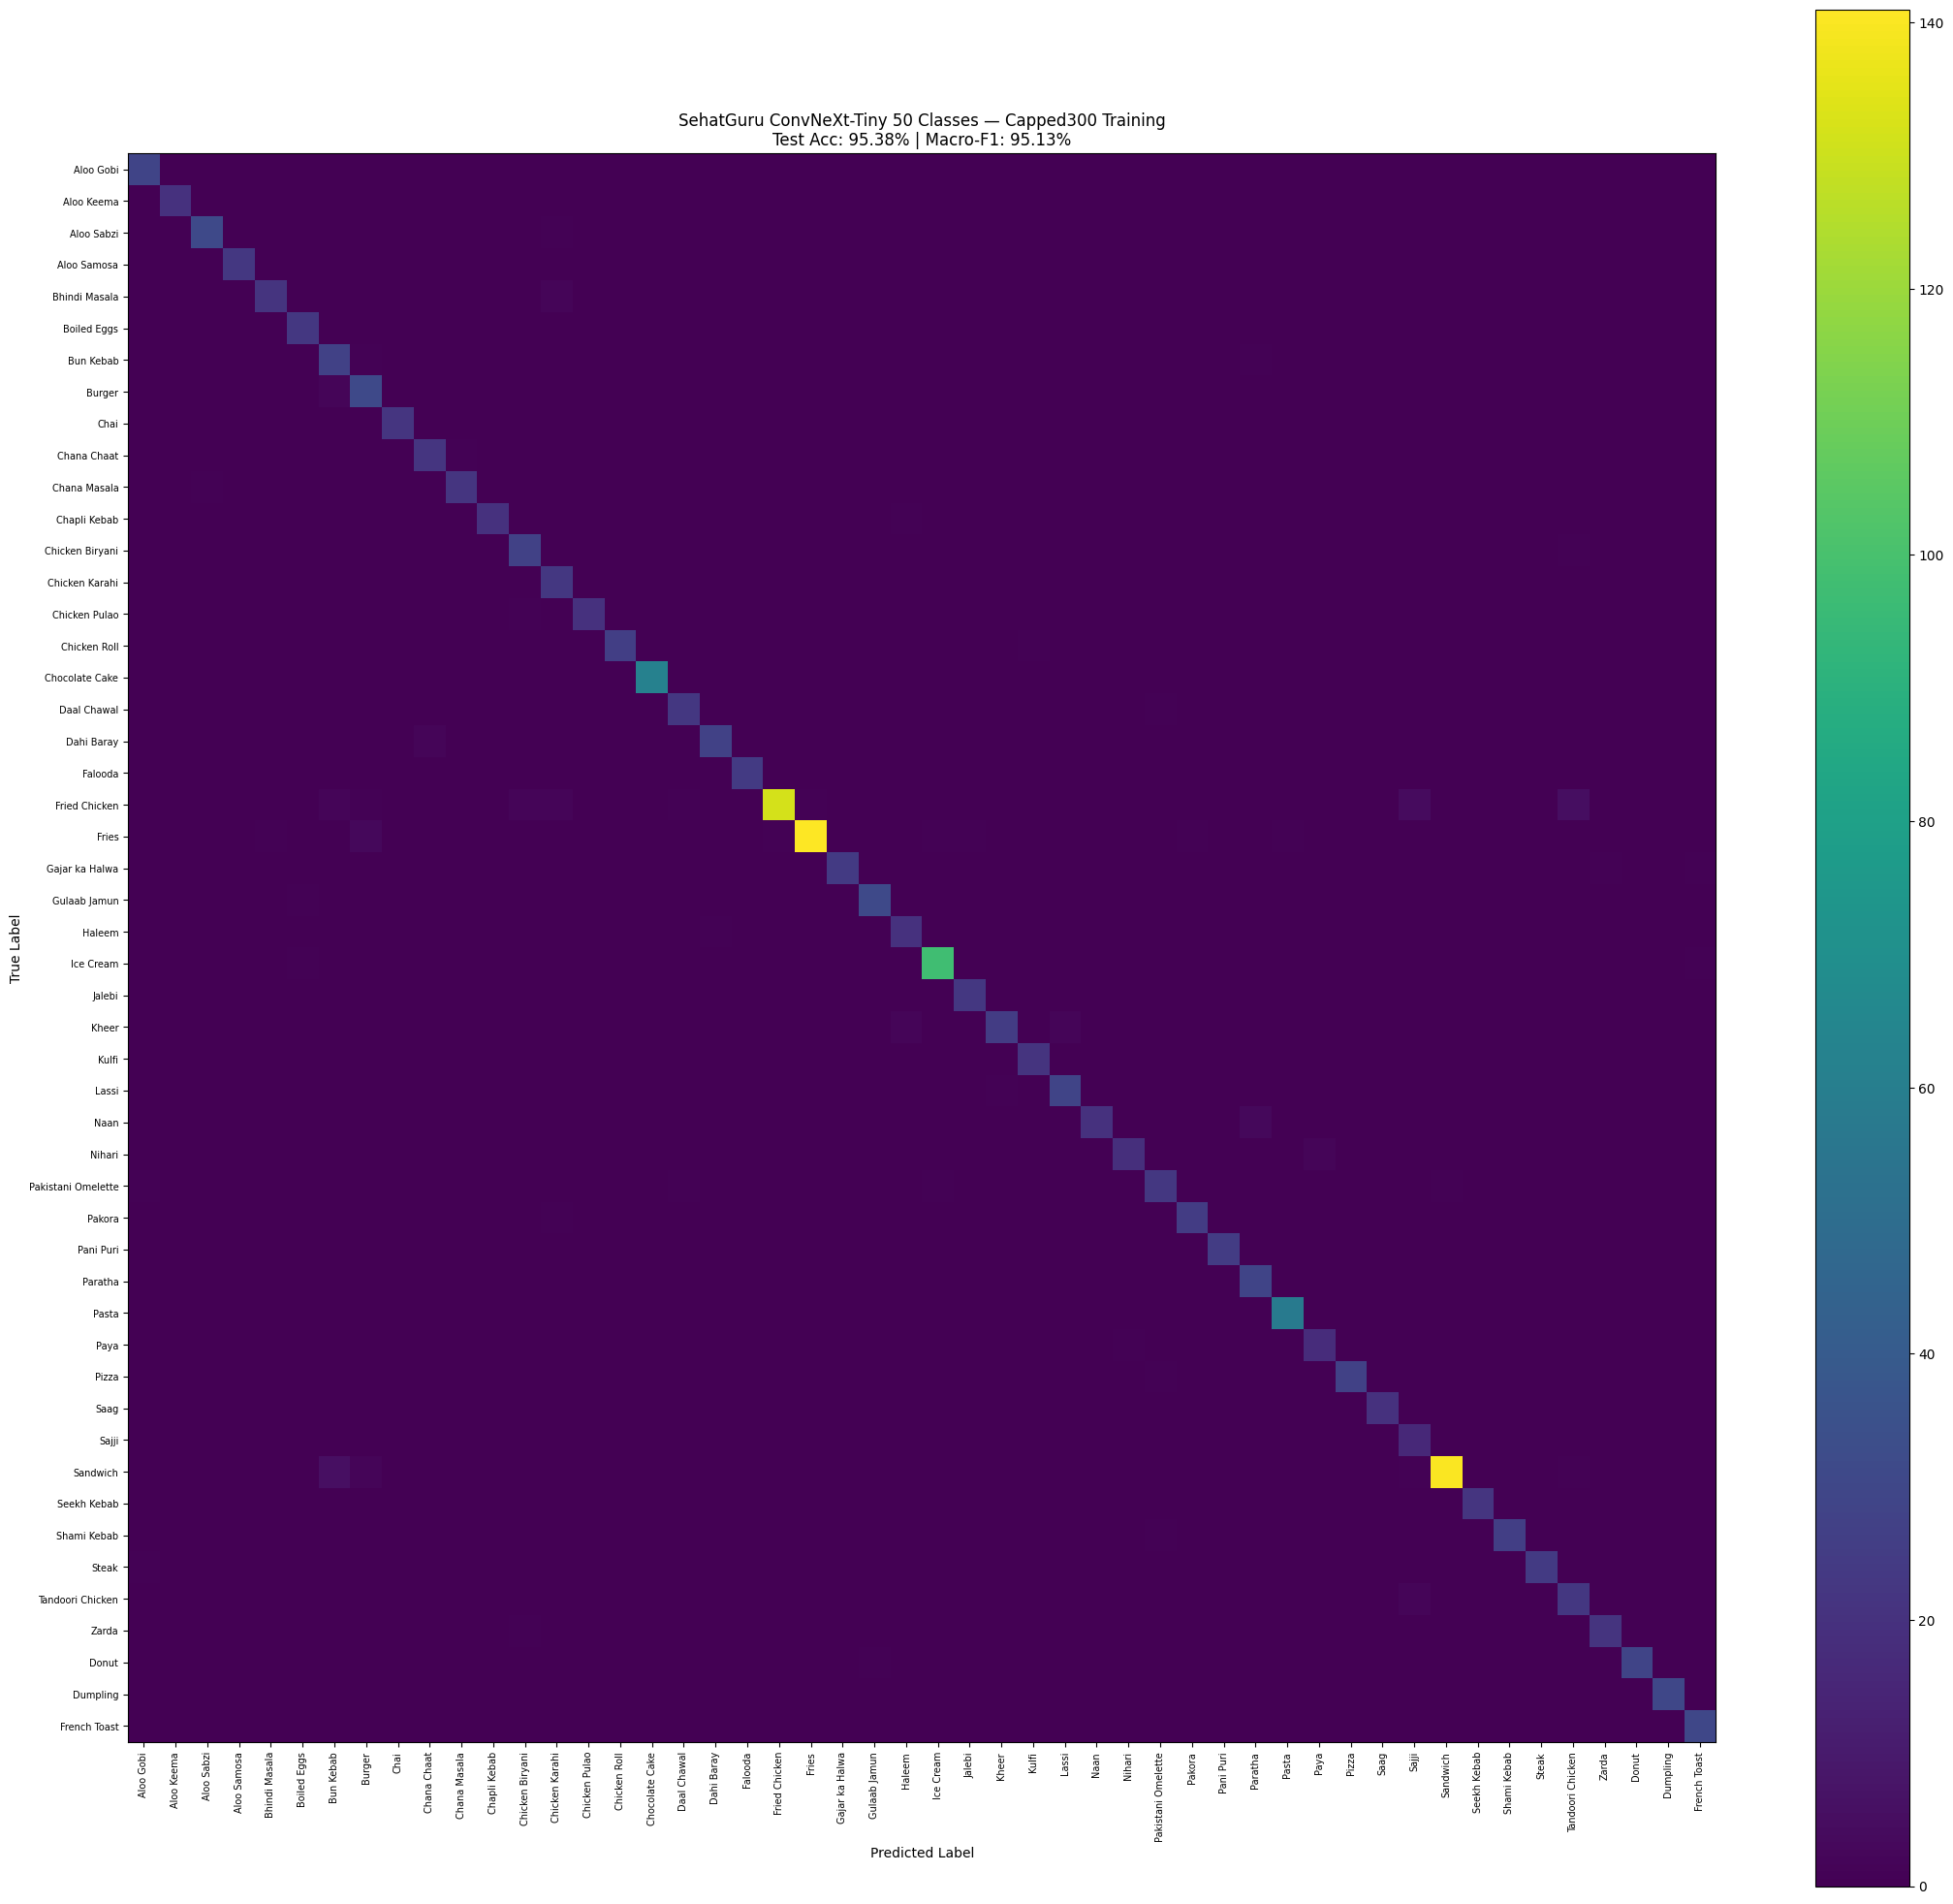

Saved confusion matrix: /kaggle/working/confusion_matrix_50_classes_capped300.png
Saved confidence report: /kaggle/working/confidence_report_50_classes_capped300.csv

Weakest classes by test accuracy/confidence:
              Dish  Samples  Accuracy  AvgConfidence  WrongCount
Pakistani Omelette       27 85.185185      81.905586           4
             Kheer       29 86.206897      87.843445           4
              Naan       23 86.956522      94.339218           3
     Fried Chicken      150 88.000000      85.358788          18
            Nihari       21 90.476190      84.581421           2
     Bhindi Masala       23 91.304348      87.974846           2
  Tandoori Chicken       25 92.000000      89.328362           2
    Gajar ka Halwa       26 92.307692      90.242355           2
         Bun Kebab       29 93.103448      90.177841           2
        Dahi Baray       29 93.103448      92.982864           2
          Sandwich      150 93.333333      89.807213          10
        

In [30]:
##### ==================================================================================
# 13. FINAL TEST EVALUATION
# ==================================================================================

print("\n" + "=" * 90)
print("FINAL TEST EVALUATION — CAPPED TRAINING VERSION")
print("=" * 90)

final_model = ConvNeXtFoodModel(n_classes=n_classes).to(DEVICE)
best_ckpt = load_model_weights(FINAL_CKPT, final_model)

final_model.eval()

test_metrics = evaluate_model(
    final_model,
    test_loader,
    criterion=criterion,
    use_tta=True,
)

y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]
confidences = test_metrics["confidences"]

print(
    f"\nTest Acc: {test_metrics['acc']:.2f}% | "
    f"Test Macro-F1: {test_metrics['macro_f1']:.2f}% | "
    f"Test Weighted-F1: {test_metrics['weighted_f1']:.2f}%"
)

print("\nClassification Report:")

report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0,
)

print(report_text)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(REPORT_CSV)

print(f"Saved classification report: {REPORT_CSV}")


# ==================================================================================
# 14. CONFUSION MATRIX
# ==================================================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(n_classes)),
)

plt.figure(figsize=(22, 20))
plt.imshow(cm, interpolation="nearest")
plt.title(
    f"SehatGuru ConvNeXt-Tiny 50 Classes — Capped300 Training\n"
    f"Test Acc: {test_metrics['acc']:.2f}% | Macro-F1: {test_metrics['macro_f1']:.2f}%"
)

plt.colorbar()

tick_marks = np.arange(n_classes)

plt.xticks(tick_marks, class_names, rotation=90, fontsize=7)
plt.yticks(tick_marks, class_names, fontsize=7)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

plt.savefig(CONFUSION_PNG, dpi=200)
plt.show()

print(f"Saved confusion matrix: {CONFUSION_PNG}")


# ==================================================================================
# 15. CONFIDENCE REPORT
# ==================================================================================

pred_df = pd.DataFrame({
    "true_id": y_true,
    "pred_id": y_pred,
    "confidence": confidences,
})

pred_df["true_label"] = pred_df["true_id"].apply(lambda x: class_names[x])
pred_df["pred_label"] = pred_df["pred_id"].apply(lambda x: class_names[x])
pred_df["correct"] = pred_df["true_id"] == pred_df["pred_id"]

stats = []

for class_id, dish in enumerate(class_names):
    dish_df = pred_df[pred_df["true_id"] == class_id]

    if len(dish_df) == 0:
        continue

    stats.append({
        "Dish": dish,
        "Samples": len(dish_df),
        "Accuracy": dish_df["correct"].mean() * 100,
        "AvgConfidence": dish_df["confidence"].mean() * 100,
        "WrongCount": int((~dish_df["correct"]).sum()),
    })

stats_df = pd.DataFrame(stats).sort_values(
    by=["Accuracy", "AvgConfidence"],
    ascending=[True, True],
)

stats_df.to_csv(CONFIDENCE_CSV, index=False)

print(f"Saved confidence report: {CONFIDENCE_CSV}")
print("\nWeakest classes by test accuracy/confidence:")
print(stats_df.head(15).to_string(index=False))


# ==================================================================================
# 16. HARD EXAMPLES EXPORT
# ==================================================================================

test_paths = [dataset.sample_paths[i] for i in test_idx]

pred_df["image_path"] = test_paths

hard_examples = pred_df[pred_df["correct"] == False].copy()
hard_examples = hard_examples.sort_values(
    by="confidence",
    ascending=False,
)

hard_examples.to_csv(HARD_EXAMPLES_CSV, index=False)

print(f"Saved hard examples: {HARD_EXAMPLES_CSV}")

print("\nMost confident wrong predictions:")

if len(hard_examples) > 0:
    print(
        hard_examples[
            ["image_path", "true_label", "pred_label", "confidence"]
        ].head(20).to_string(index=False)
    )
else:
    print("No wrong predictions in the test set.")


# ==================================================================================
# 17. CONFUSION PAIR ANALYSIS
# ==================================================================================

pairs = []

for true_id in range(n_classes):
    for pred_id in range(n_classes):
        if true_id == pred_id:
            continue

        count = cm[true_id, pred_id]

        if count > 0:
            pairs.append({
                "true_label": class_names[true_id],
                "predicted_as": class_names[pred_id],
                "count": int(count),
            })

pairs_df = pd.DataFrame(pairs)

if len(pairs_df) > 0:
    pairs_df = pairs_df.sort_values(
        by="count",
        ascending=False,
    )

    pairs_df.to_csv(CONFUSION_PAIRS_CSV, index=False)

    print(f"Saved confusion pairs: {CONFUSION_PAIRS_CSV}")
    print("\nTop confused dish pairs:")
    print(pairs_df.head(20).to_string(index=False))

else:
    pairs_df.to_csv(CONFUSION_PAIRS_CSV, index=False)
    print("No confusion pairs found.")


# ==================================================================================
# 18. ZIP OUTPUTS FOR DOWNLOAD
# ==================================================================================

print("\n" + "=" * 90)
print("ZIPPING OUTPUTS FOR DOWNLOAD")
print("=" * 90)

# Include cap report in output folder too
output_dir = "/kaggle/working/sehatguru_capped400_outputs"

shutil.rmtree(output_dir, ignore_errors=True)
os.makedirs(output_dir, exist_ok=True)

output_files = [
    FOOD101_CKPT,
    FINAL_CKPT,
    LAST_CKPT,
    CONFUSION_PNG,
    CONFIDENCE_CSV,
    REPORT_CSV,
    HARD_EXAMPLES_CSV,
    CONFUSION_PAIRS_CSV,
    SPLIT_JSON,
    TRAINING_HISTORY_CSV,
    cap_report_path,
]

for file_path in output_files:
    if os.path.exists(file_path):
        shutil.copy(file_path, output_dir)
        print("Copied:", os.path.basename(file_path))
    else:
        print("Missing:", file_path)

if os.path.exists(OUTPUT_ZIP):
    os.remove(OUTPUT_ZIP)

shutil.make_archive(
    OUTPUT_ZIP.replace(".zip", ""),
    "zip",
    output_dir,
)

print("\nCreated output zip:")
print(OUTPUT_ZIP)


# ==================================================================================
# 19. FINAL SUMMARY
# ==================================================================================

print("\n" + "=" * 90)
print("PIPELINE COMPLETE — CAPPED TRAINING VERSION")
print("=" * 90)

print("Best capped SehatGuru checkpoint:")
print(FINAL_CKPT)

print("\nFinal test results:")
print(f"Test Accuracy: {test_metrics['acc']:.2f}%")
print(f"Test Macro-F1: {test_metrics['macro_f1']:.2f}%")
print(f"Test Weighted-F1: {test_metrics['weighted_f1']:.2f}%")

print("\nDownload this zip from Kaggle output files:")
print(OUTPUT_ZIP)

print("\nImportant:")
print("Compare this capped model with your previous model:")
print("Previous model: Test Accuracy 94.25%, Macro-F1 92.97%, Weighted-F1 94.20%")
print("Use whichever model has better Macro-F1 and better weak-class performance.")
print("Use class_names stored inside the checkpoint during inference.")

Validation dataset checking


================ DATASET INFO ================
Total validation images: 516
Classes found: ['Aloo Gobi', 'Aloo Keema', 'Aloo Sabzi', 'Aloo Samosa', 'Bhindi Masala', 'Boiled Eggs', 'Bun Kebab', 'Burger', 'Chai', 'Chana Chaat', 'Chana Masala', 'Chapli Kebab', 'Chicken Biryani', 'Chicken Karahi', 'Chicken Pulao', 'Chicken Roll', 'Chocolate Cake', 'Daal Chawal', 'Dahi Baray', 'Donut', 'Dumpling', 'Falooda', 'French Toast', 'Fried Chicken', 'Fries', 'Gajar ka Halwa', 'Gulaab Jamun', 'Haleem', 'Ice Cream', 'Jalebi', 'Kheer', 'Kulfi', 'Lassi', 'Naan', 'Nihari', 'Pakistani Omelette', 'Pakora', 'Pani Puri', 'Paratha', 'Pasta', 'Paya', 'Pizza', 'Saag', 'Sajji', 'Sandwich', 'Seekh Kebab', 'Shami Kebab', 'Steak', 'Tandoori Chicken', 'Zarda']
Final eval images: 516

Missing keys: 0
Unexpected keys: 0

FINAL RESULTS
Accuracy       : 0.8663
Macro F1       : 0.8672
Weighted F1    : 0.8676
Avg Confidence : 0.8417

Classification Report:
                    precision    recall  f1-score   support

    

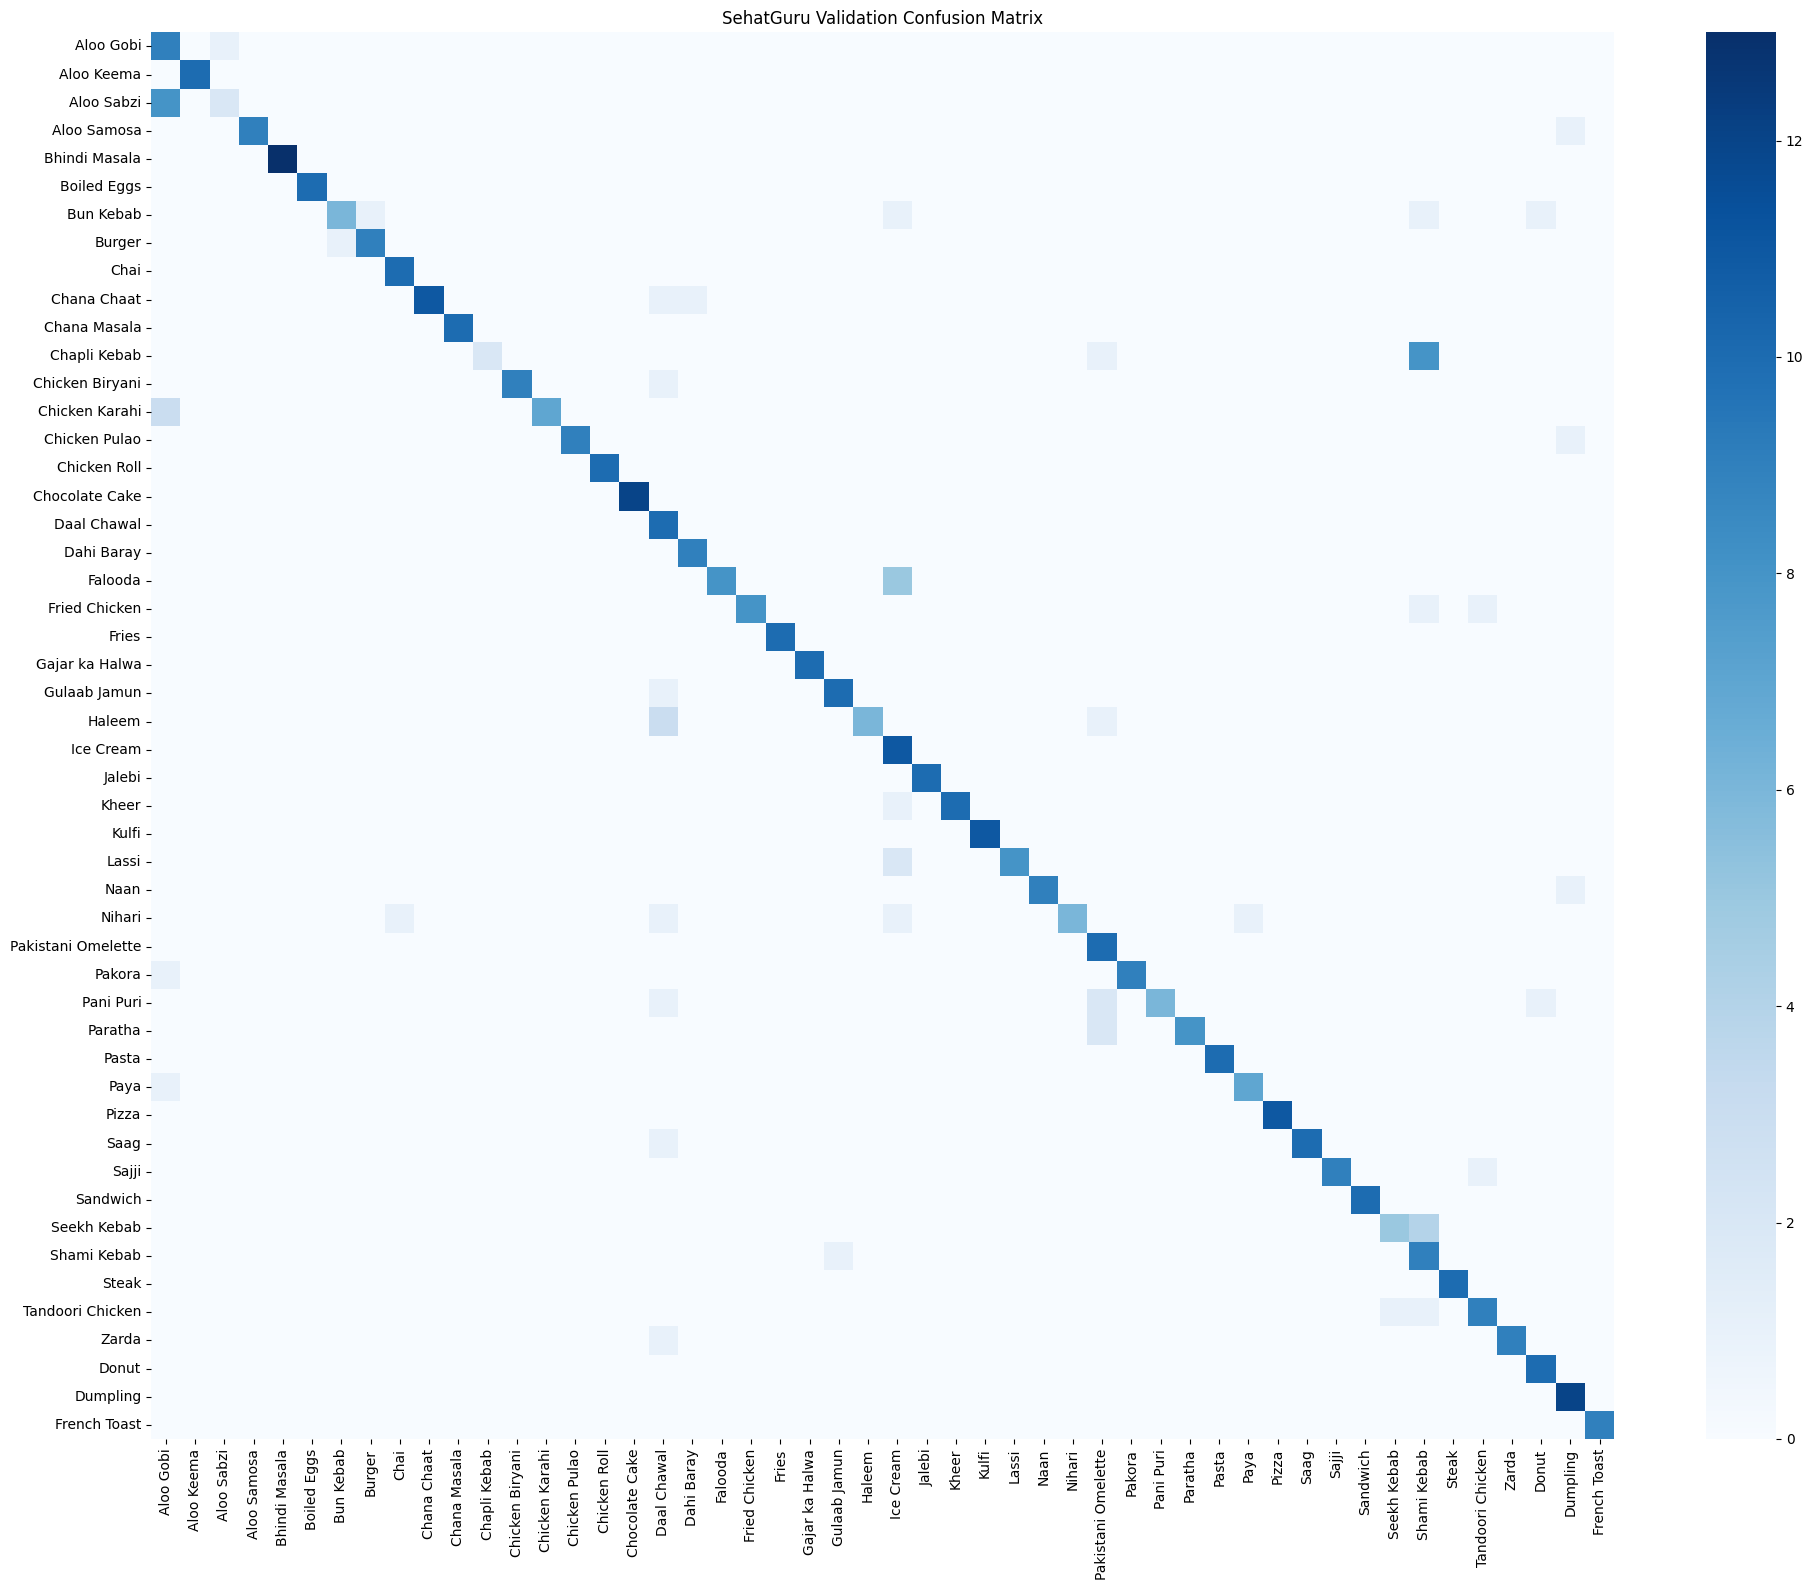


Lowest confidence predictions:
         true_class      pred_class  confidence  correct
273    Gulaab Jamun     Daal Chawal    0.253890    False
30      Aloo Samosa        Dumpling    0.269225    False
3         Aloo Gobi      Aloo Sabzi    0.279276    False
67        Bun Kebab       Bun Kebab    0.297309     True
146  Chicken Karahi  Chicken Karahi    0.302814     True
143  Chicken Karahi  Chicken Karahi    0.305977     True
4         Aloo Gobi       Aloo Gobi    0.328412     True
381          Pakora       Aloo Gobi    0.337701    False
359          Nihari            Chai    0.357209    False
246   Fried Chicken   Fried Chicken    0.359727     True
62      Boiled Eggs     Boiled Eggs    0.364130     True
156   Chicken Pulao        Dumpling    0.365700    False
515           Zarda           Zarda    0.372133     True
89             Chai            Chai    0.378949     True
423            Paya            Paya    0.385462     True
93      Chana Chaat     Chana Chaat    0.400912     True

In [52]:
# ==================================================================================
# SEHATGURU REAL-WORLD VALIDATION SCRIPT (MATCHES TRAINING CONFIG)
# ==================================================================================

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import timm

# ==================================================================================
# CONFIG
# ==================================================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

VAL_DIR = "/kaggle/input/datasets/ahtishamuwu/validation-50/validation"
CKPT_PATH = "/kaggle/working/SehatGuru_DINOv2_50_capped300_best_macroF1.pth"
BATCH_SIZE = 32

IMG_SIZE = 252  # matches original training

TRAIN_CLASSES = [
    "Aloo Gobi","Aloo Keema","Aloo Sabzi","Aloo Samosa","Bhindi Masala",
    "Boiled Eggs","Bun Kebab","Burger","Chai","Chana Chaat",
    "Chana Masala","Chapli Kebab","Chicken Biryani","Chicken Karahi",
    "Chicken Pulao","Chicken Roll","Chocolate Cake","Daal Chawal",
    "Dahi Baray","Falooda","Fried Chicken","Fries","Gajar ka Halwa",
    "Gulaab Jamun","Haleem","Ice Cream","Jalebi","Kheer","Kulfi","Lassi",
    "Naan","Nihari","Pakistani Omelette","Pakora","Pani Puri","Paratha",
    "Pasta","Paya","Pizza","Saag","Sajji","Sandwich","Seekh Kebab",
    "Shami Kebab","Steak","Tandoori Chicken","Zarda","Donut","Dumpling",
    "French Toast"
]

NUM_CLASSES = len(TRAIN_CLASSES)
class_to_idx = {c: i for i, c in enumerate(TRAIN_CLASSES)}

# ==================================================================================
# TRANSFORM
# ==================================================================================

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

print("\n================ DATASET INFO ================")
print("Total validation images:", len(dataset))
print("Classes found:", dataset.classes)

samples = []
for path, label in dataset.samples:
    cls_name = dataset.classes[label]
    if cls_name in class_to_idx:
        samples.append((path, class_to_idx[cls_name]))

dataset.samples = samples
dataset.targets = [s[1] for s in samples]

print("Final eval images:", len(dataset))

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ==================================================================================
# MODEL
# ==================================================================================

class SehatGuruDINOv2(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.backbone = timm.create_model(
            "vit_base_patch14_reg4_dinov2.lvd142m",
            pretrained=False,
            img_size=IMG_SIZE,
            num_classes=0
        )
        feat_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        x = self.backbone(x)
        if isinstance(x, (tuple, list)):
            x = x[0]
        return self.head(x)

# ==================================================================================
# LOAD CHECKPOINT
# ==================================================================================

def load_checkpoint(model, path):
    ckpt = torch.load(path, map_location=DEVICE)
    state_dict = ckpt.get("model_state_dict", ckpt)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print("\nMissing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))
    return model

# ==================================================================================
# LOAD MODEL
# ==================================================================================

if not os.path.exists(CKPT_PATH):
    raise FileNotFoundError(f"Checkpoint not found: {CKPT_PATH}")

model = SehatGuruDINOv2(NUM_CLASSES).to(DEVICE)
model = load_checkpoint(model, CKPT_PATH)
model.eval()

# ==================================================================================
# EVALUATION
# ==================================================================================

y_true, y_pred, confs = [], [], []
softmax = nn.Softmax(dim=1)

with torch.no_grad():
    for images, labels in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = softmax(outputs)
        preds = torch.argmax(probs, dim=1)
        conf = torch.max(probs, dim=1)[0]

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        confs.extend(conf.cpu().numpy())

# ==================================================================================
# FINAL RESULTS & METRICS
# ==================================================================================

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
avg_conf = np.mean(confs)

print("\n==========================================================================================")
print("FINAL RESULTS")
print("==========================================================================================")
print(f"Accuracy       : {acc:.4f}")
print(f"Macro F1       : {f1_macro:.4f}")
print(f"Weighted F1    : {f1_weighted:.4f}")
print(f"Avg Confidence : {avg_conf:.4f}")

# ==================================================================================
# REPORT
# ==================================================================================

report_str = classification_report(
    y_true, 
    y_pred, 
    labels=list(range(NUM_CLASSES)), 
    target_names=TRAIN_CLASSES, 
    zero_division=0
)
print("\nClassification Report:")
print(report_str)

df_report = pd.DataFrame(
    classification_report(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), 
        target_names=TRAIN_CLASSES, output_dict=True, zero_division=0
    )
).transpose()
df_report.to_csv("/kaggle/working/classification_report.csv")

# ==================================================================================
# CONFUSION MATRIX
# ==================================================================================

print("\nGenerating confusion matrix...")
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(20, 16))
sns.heatmap(cm, cmap="Blues", xticklabels=TRAIN_CLASSES, yticklabels=TRAIN_CLASSES)
plt.title("SehatGuru Validation Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==================================================================================
# ERROR ANALYSIS
# ==================================================================================

df_conf = pd.DataFrame({
    "true_class": [TRAIN_CLASSES[i] for i in y_true],
    "pred_class": [TRAIN_CLASSES[i] for i in y_pred],
    "confidence": confs
})
df_conf["correct"] = df_conf["true_class"] == df_conf["pred_class"]
df_conf.to_csv("/kaggle/working/confidence.csv", index=False)

print("\nLowest confidence predictions:")
print(df_conf.sort_values(by="confidence").head(20))

wrong_preds = df_conf[df_conf["correct"] == False]
print(f"\nTotal wrong predictions: {len(wrong_preds)}")

print("\nMost common mistakes:")
mistake_counts = wrong_preds.groupby(["true_class", "pred_class"]).size().sort_values(ascending=False)
print(mistake_counts.head(20))

print("\nDone.")


Generating high-definition confusion matrix...

HD Confusion Matrix saved successfully at: /kaggle/working/sehatguru_confusion_matrix_hd.png


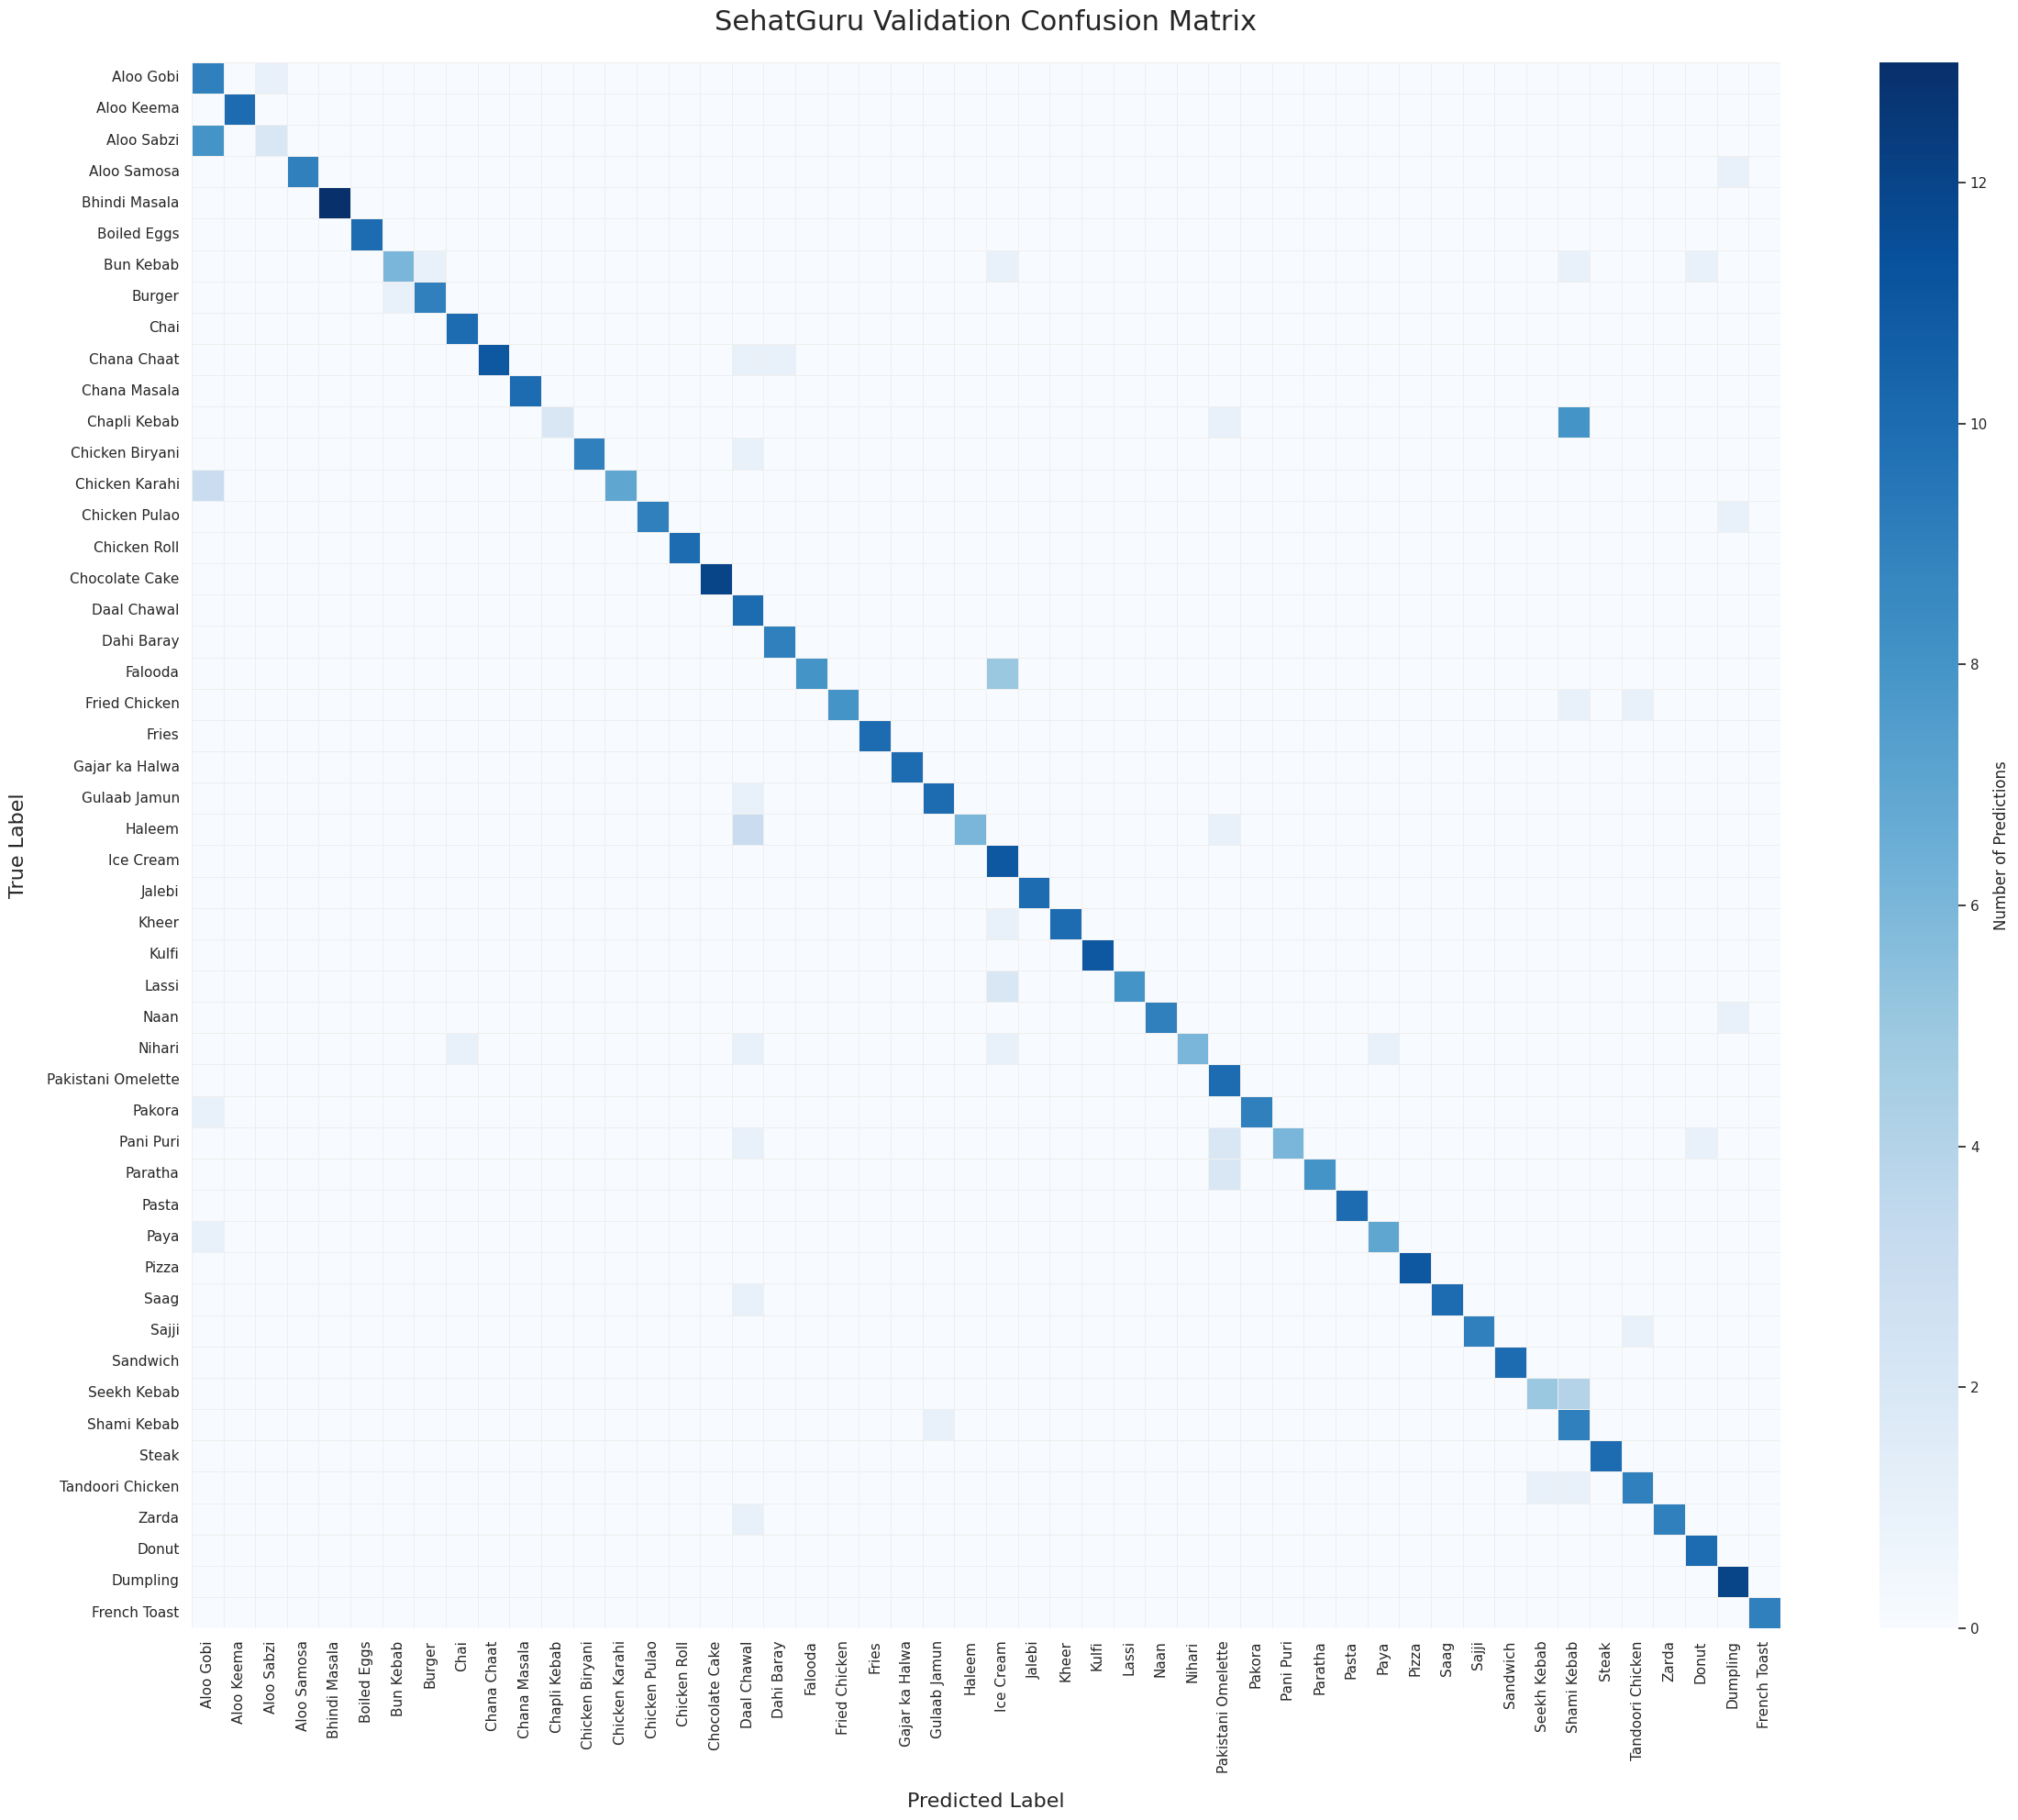

In [53]:
# ==================================================================================
# CONFUSION MATRIX (HIGH-DEFINITION EXPORT)
# ==================================================================================

print("\nGenerating high-definition confusion matrix...")
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

# Setting up a high-resolution canvas
plt.figure(figsize=(24, 20)) 
sns.set_theme(style="white")

# Plotting with explicit line widths for a sharp grid
sns.heatmap(
    cm, 
    cmap="Blues", 
    xticklabels=TRAIN_CLASSES, 
    yticklabels=TRAIN_CLASSES,
    linewidths=0.5,
    linecolor='#eeeeee', # Subtle grid lines
    cbar_kws={'label': 'Number of Predictions'}
)

plt.title("SehatGuru Validation Confusion Matrix", fontsize=22, pad=25)
plt.xlabel("Predicted Label", fontsize=16, labelpad=15)
plt.ylabel("True Label", fontsize=16, labelpad=15)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Ensuring labels aren't cut off
plt.tight_layout()

# Saving as PNG with 300 DPI for professional HD quality
# bbox_inches='tight' ensures all labels are fully included in the file
save_path = "/kaggle/working/sehatguru_confusion_matrix_hd.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"\nHD Confusion Matrix saved successfully at: {save_path}")
plt.show()

In [15]:
import torch

path1 = "/kaggle/working/sehatguru_capped400_outputs/SehatGuru_ConvNeXt_50_capped300_best_macroF1.pth"
path2 = "/kaggle/working/SehatGuru_ConvNeXt_50_capped300_best_macroF1.pth"

ckpt1 = torch.load(path1, map_location="cpu")
ckpt2 = torch.load(path2, map_location="cpu")

print("PATH 1")
print("Best Macro F1:", ckpt1.get("best_macro_f1"))
print("Created:", ckpt1.get("created_at"))

print("\nPATH 2")
print("Best Macro F1:", ckpt2.get("best_macro_f1"))
print("Created:", ckpt2.get("created_at"))

PATH 1
Best Macro F1: 93.64809691370021
Created: 2026-05-14 12:55:22

PATH 2
Best Macro F1: 93.64809691370021
Created: 2026-05-14 12:55:22


run this to download the zip file if it doesnt donwload from outputs

In [ ]:
from IPython.display import FileLink, display
import os

zip_path = "/kaggle/working/sehatguru_50_capped300_training_outputs.zip"

print("Exists:", os.path.exists(zip_path))
print("Size MB:", os.path.getsize(zip_path) / (1024 * 1024) if os.path.exists(zip_path) else "missing")

display(FileLink("sehatguru_50_capped300_training_outputs.zip"))

image distribution per class 

In [ ]:
# ==================================================================================
# IMAGE DISTRIBUTION PER CLASS AFTER CAPPING TO 300 — SEHATGURU 50 DATASET
# ==================================================================================

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATASET_DIR = "/kaggle/input/datasets/ahtishamuwu/sehatguru-dishes-50/50_dishes_dataset"

CAP_PER_CLASS = 300

OUTPUT_CSV = "/kaggle/working/class_image_distribution_capped300.csv"
OUTPUT_PNG = "/kaggle/working/class_image_distribution_capped300.png"
OUTPUT_COMPARE_PNG = "/kaggle/working/class_image_distribution_original_vs_capped300.png"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Check dataset path
if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(f"Dataset not found at: {DATASET_DIR}")

class_counts = []

for class_name in sorted(os.listdir(DATASET_DIR)):
    class_path = Path(DATASET_DIR) / class_name

    if not class_path.is_dir():
        continue

    image_files = [
        file for file in class_path.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    original_count = len(image_files)
    capped_count = min(original_count, CAP_PER_CLASS)

    class_counts.append({
        "class_name": class_name,
        "original_image_count": original_count,
        "capped_image_count": capped_count,
        "removed_by_cap": original_count - capped_count
    })

df = pd.DataFrame(class_counts)

# Sort by capped count first, then original count
df = df.sort_values(
    by=["capped_image_count", "original_image_count"],
    ascending=[False, False]
).reset_index(drop=True)

# Save CSV
df.to_csv(OUTPUT_CSV, index=False)

print("=" * 90)
print("CLASS IMAGE DISTRIBUTION AFTER CAPPING TO 300")
print("=" * 90)

print(df.to_string(index=False))

print("\nSummary After Capping:")
print(f"Total classes: {len(df)}")
print(f"Original total images: {df['original_image_count'].sum()}")
print(f"Capped total images: {df['capped_image_count'].sum()}")
print(f"Total images removed by cap: {df['removed_by_cap'].sum()}")
print(f"Minimum capped images in a class: {df['capped_image_count'].min()}")
print(f"Maximum capped images in a class: {df['capped_image_count'].max()}")
print(f"Mean capped images per class: {df['capped_image_count'].mean():.2f}")
print(f"Median capped images per class: {df['capped_image_count'].median():.2f}")

print("\nSaved CSV:")
print(OUTPUT_CSV)

# ==================================================================================
# Plot 1: Capped distribution only
# ==================================================================================

plt.figure(figsize=(18, 10))

plt.bar(df["class_name"], df["capped_image_count"])

plt.title("Image Distribution per Class After Capping at 300 — SehatGuru 50 Classes", fontsize=16)
plt.xlabel("Food Class", fontsize=12)
plt.ylabel("Number of Images After Cap", fontsize=12)

plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()

plt.savefig(OUTPUT_PNG, dpi=200)
plt.show()

print("\nSaved capped chart:")
print(OUTPUT_PNG)


# ==================================================================================
# Plot 2: Original vs capped comparison
# ==================================================================================

df_compare = df.sort_values(by="original_image_count", ascending=False).reset_index(drop=True)

x = range(len(df_compare))
width = 0.4

plt.figure(figsize=(20, 10))

plt.bar(
    [i - width / 2 for i in x],
    df_compare["original_image_count"],
    width=width,
    label="Original"
)

plt.bar(
    [i + width / 2 for i in x],
    df_compare["capped_image_count"],
    width=width,
    label="Capped at 300"
)

plt.title("Original vs Capped Image Distribution — SehatGuru 50 Classes", fontsize=16)
plt.xlabel("Food Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

plt.xticks(x, df_compare["class_name"], rotation=90, fontsize=8)
plt.legend()
plt.tight_layout()

plt.savefig(OUTPUT_COMPARE_PNG, dpi=200)
plt.show()

print("\nSaved original vs capped comparison chart:")
print(OUTPUT_COMPARE_PNG)